**Análise Exploratória de Dados de Espermogramas utilizando Python**

Objetivo

Neste notebook será realizada uma análise exploratória de um conjunto de dados sintético de espermogramas utilizando Python e a biblioteca Pandas.

Serão apresentados os principais passos da análise de dados, como:

*   Importação da base de dados;
*   Exploração das informações;
*   Cálculo de estatísticas descritivas;
*   Visualização gráfica dos resultados.

O objetivo é demonstrar como a programação pode auxiliar na organização e interpretação de dados biomédicos.

**Importação das bibliotecas**

In [17]:
# Importando as bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Importação da base de dados**

In [18]:
# Importando a planilha

df = pd.read_excel("espermograma_dataset_sintetico (1).xlsx")

In [20]:
# Visualizando as primeiras linhas da tabela

df.head()

,ID_Paciente,Idade,Dias de Abstinencia,Volume - mL,pH,Concentração - milhoes/mL,Motilidade Total - %,Motilidade Progressiva - %,Morfologia - %,Vitalidade - %,Leucócitos - milhoes/mL,Diagnóstico Principal,Classificação
0,1,22,7,3.9,7.5,91.4,48.8,34.4,1.5,55.9,0.47,Teratozoospermia,Alterado
1,2,22,6,3.8,7.4,63.6,20.4,10.3,7.5,68.3,0.80,Astenozoospermia,Alterado
2,3,44,5,2.5,7.5,3.2,60.3,34.2,7.4,66.1,0.75,Oligozoospermia,Alterado
3,4,39,2,2.6,8.2,9.2,72.6,51.1,6.5,75.2,0.92,Oligozoospermia,Alterado
4,5,23,7,2.4,7.4,28.1,57.2,39.8,2.2,65.9,0.38,Teratozoospermia,Alterado


**Padronização das colunas**

In [21]:
# Padronizando os nomes das colunas

df = df.rename(columns={
    "Dias de Abstinencia": "Dias_Abstinencia",
    "Volume - mL": "Volume",
    "Concentração - milhoes/mL": "Concentracao",
    "Motilidade Total - %": "Motilidade_Total",
    "Motilidade Progressiva - %": "Motilidade_Progressiva",
    "Morfologia - %": "Morfologia",
    "Vitalidade - %": "Vitalidade",
    "Leucócitos - milhoes/mL": "Leucocitos",
    "Diagnóstico Principal": "Diagnostico",
    "Classificação": "Classificacao"
})

In [22]:
df.columns

Index(['ID_Paciente', 'Idade', 'Dias_Abstinencia', 'Volume', 'pH',
       'Concentracao', 'Motilidade_Total', 'Motilidade_Progressiva',
       'Morfologia', 'Vitalidade', 'Leucocitos', 'Diagnostico',
       'Classificacao'],
      dtype='object')

**Exploração inicial dos dados**

In [23]:
# Informações gerais da base de dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Paciente             300 non-null    int64  
 1   Idade                   300 non-null    int64  
 2   Dias_Abstinencia        300 non-null    int64  
 3   Volume                  300 non-null    float64
 4   pH                      300 non-null    float64
 5   Concentracao            300 non-null    float64
 6   Motilidade_Total        300 non-null    float64
 7   Motilidade_Progressiva  300 non-null    float64
 8   Morfologia              300 non-null    float64
 9   Vitalidade              300 non-null    float64
 10  Leucocitos              300 non-null    float64
 11  Diagnostico             300 non-null    object 
 12  Classificacao           300 non-null    object 
dtypes: float64(8), int64(3), object(2)
memory usage: 30.6+ KB


**Estatísticas descritivas**

In [25]:
# Quantidade de pacientes

print("Número de pacientes:", len(df))

Número de pacientes: 300


In [26]:
# Idade média dos pacientes

print("Idade média:", round(df["Idade"].mean(),1), "anos")

Idade média: 36.9 anos


In [27]:
# Concentração média

print("Concentração média:", round(df["Concentracao"].mean(),1), "milhões/mL")

Concentração média: 50.4 milhões/mL


In [28]:
# Motilidade progressiva média

print("Motilidade progressiva média:", round(df["Motilidade_Progressiva"].mean(),1), "%")

Motilidade progressiva média: 38.9 %


In [29]:
# Quantidade de exames por classificação

df["Classificacao"].value_counts()

,count
Classificacao,
Alterado,160
Normal,140


**Visualização gráfica**

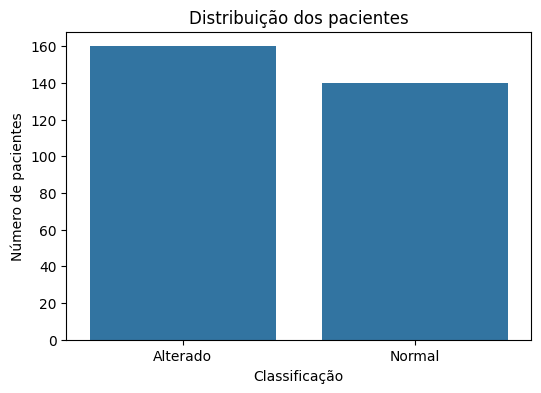

In [30]:
# Gráfico da classificação dos pacientes

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Classificacao")

plt.title("Distribuição dos pacientes")
plt.xlabel("Classificação")
plt.ylabel("Número de pacientes")

plt.show()

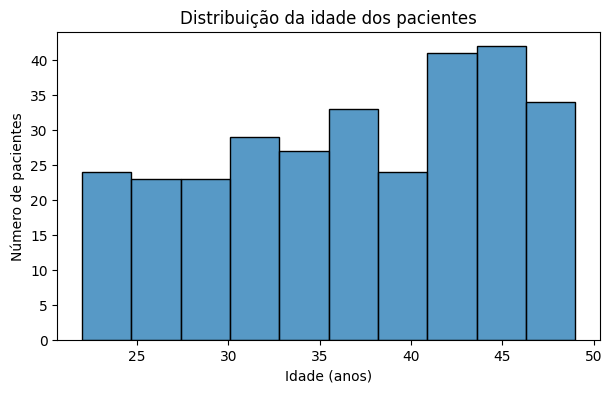

In [33]:
plt.figure(figsize=(7,4))

sns.histplot(df["Idade"], bins=10)

plt.title("Distribuição da idade dos pacientes")
plt.xlabel("Idade (anos)")
plt.ylabel("Número de pacientes")

plt.show()

In [34]:
# Classificando a morfologia segundo o critério da OMS

df["Morfologia_OMS"] = df["Morfologia"].apply(
    lambda x: "Normal (≥4%)" if x >= 4 else "Teratozoospermia (<4%)"
)

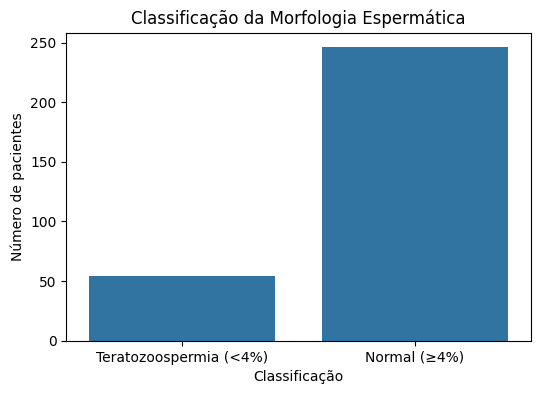

In [35]:
# Distribuição da morfologia segundo a OMS

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Morfologia_OMS")

plt.title("Classificação da Morfologia Espermática")
plt.xlabel("Classificação")
plt.ylabel("Número de pacientes")

plt.show()

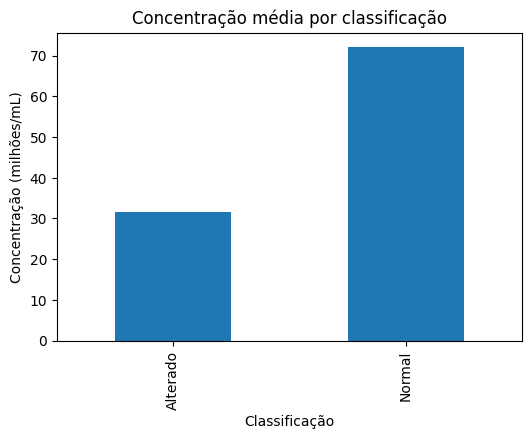

In [36]:
# Média da concentração por classificação

media_concentracao = df.groupby("Classificacao")["Concentracao"].mean()

plt.figure(figsize=(6,4))

media_concentracao.plot(kind="bar")

plt.title("Concentração média por classificação")
plt.xlabel("Classificação")
plt.ylabel("Concentração (milhões/mL)")

plt.show()

In [39]:
# Distribuição dos diagnósticos

diagnosticos = df["Diagnostico"].value_counts().reset_index()
diagnosticos.columns = ["Diagnóstico", "Número de pacientes"]

diagnosticos

,Diagnóstico,Número de pacientes
0,Normozoospermia,140
1,Astenozoospermia,49
2,Teratozoospermia,30
3,Oligozoospermia,30
4,Oligoastenozoospermia,27
5,Oligoastenoteratozoospermia,24


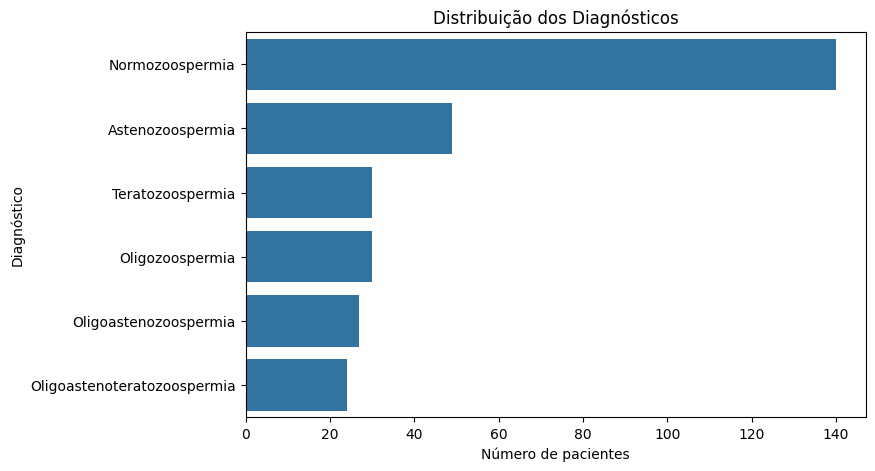

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="Diagnostico",
    order=df["Diagnostico"].value_counts().index
)

plt.title("Distribuição dos Diagnósticos")
plt.xlabel("Número de pacientes")
plt.ylabel("Diagnóstico")

plt.show()

**Conclusão**

A análise exploratória permitiu visualizar a distribuição dos pacientes, observar a faixa etária da amostra e comparar parâmetros seminais entre exames normais e alterados.

Também foi criada uma classificação específica para morfologia espermática, considerando valores abaixo de 4% como indicativos de teratozoospermia.

O uso de Python e Pandas facilitou a organização, exploração e visualização dos dados biomédicos.